In [1]:
# =========================
# Cell 1 — Imports & Setup
# =========================
import json, os, math, time
import numpy as np
import torch
import torch.nn as nn
from torch.autograd import grad
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Domain / physics
L = 2*np.pi
Re = 100.0
nu = 1.0 / Re
T_FINAL = 0.1

# Evaluation grid
N_EVAL = 32
X_EVAL = np.linspace(0, L, N_EVAL, endpoint=False)
Y_EVAL = np.linspace(0, L, N_EVAL, endpoint=False)
XX_EVAL, YY_EVAL = np.meshgrid(X_EVAL, Y_EVAL, indexing='ij')

# Reference file (N=128 recommended)
REFERENCE_NPZ = "/kaggle/input/reference-date-safe/reference_data_safe.npz"
SAVE_DIR = "./pinn_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)


In [2]:
# =========================================
# Cell 2 — Taylor–Green IC & Helper Routines
# =========================================
def tg_ic_uv(x, y):
    """Taylor–Green vortex initial condition, consistent with pseudo-spectral solver."""
    u0 = np.sin(x) * np.cos(y)
    v0 = -np.cos(x) * np.sin(y)
    return u0, v0

def vorticity_from_uv(u, v, L=2*np.pi):
    """Compute vorticity ω = ∂x v − ∂y u using spectral derivatives."""
    N = u.shape[0]
    dx = L / N
    kx = np.fft.fftfreq(N, d=dx) * 2*np.pi
    ky = np.fft.fftfreq(N, d=dx) * 2*np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    uhat = np.fft.fft2(u)
    vhat = np.fft.fft2(v)
    w_hat = 1j*KX*vhat - 1j*KY*uhat
    return np.real(np.fft.ifft2(w_hat))

def energy_spectrum(u, v, L=2*np.pi):
    """Isotropic kinetic energy spectrum E(k) via shell binning."""
    N = u.shape[0]
    dx = L / N
    uhat, vhat = np.fft.fft2(u), np.fft.fft2(v)
    Ek_grid = 0.5 * (np.abs(uhat)**2 + np.abs(vhat)**2) / (N*N)
    kx = np.fft.fftfreq(N, d=dx) * 2*np.pi
    ky = np.fft.fftfreq(N, d=dx) * 2*np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    kk = np.sqrt(KX**2 + KY**2)
    kbin = np.floor(kk).astype(int)
    kmax = N // 2
    spec = np.zeros(kmax)
    for m in range(kmax):
        mask = (kbin == m)
        if np.any(mask):
            spec[m] = Ek_grid[mask].sum()
    return np.arange(kmax), spec

def interp_periodic(field_ref, x_ref, y_ref, x_tgt, y_tgt):
    """Periodic interpolation of reference field onto target grid."""
    interp = RegularGridInterpolator((x_ref, y_ref), field_ref, bounds_error=False, fill_value=None)
    XT, YT = np.meshgrid(x_tgt, y_tgt, indexing='ij')
    pts = np.stack([XT.ravel() % (2*np.pi), YT.ravel() % (2*np.pi)], axis=-1)
    return interp(pts).reshape(XT.shape)

def compare_vorticity_to_reference(w_pred, x_pred, y_pred, ref_npz=REFERENCE_NPZ):
    data = np.load(ref_npz)
    u_ref, v_ref = data["u"], data["v"]  # shape Nref x Nref at t=1
    Nref = u_ref.shape[0]
    xr = np.linspace(0, 2*np.pi, Nref, endpoint=False)
    yr = np.linspace(0, 2*np.pi, Nref, endpoint=False)

    # Reference vorticity
    dxr = 2*np.pi / Nref
    kx = np.fft.fftfreq(Nref, d=dxr) * 2*np.pi
    ky = np.fft.fftfreq(Nref, d=dxr) * 2*np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    w_ref = np.real(np.fft.ifft2(1j*KX*np.fft.fft2(v_ref) - 1j*KY*np.fft.fft2(u_ref)))

    w_ref_on_pred = interp_periodic(w_ref, xr, yr, x_pred, y_pred)

    # Auto sign check (phase ambiguity)
    c1 = np.corrcoef(w_pred.ravel(), w_ref_on_pred.ravel())[0, 1]
    c2 = np.corrcoef((-w_pred).ravel(), w_ref_on_pred.ravel())[0, 1]
    if abs(c2) > abs(c1):
        w_pred = -w_pred
        corr = c2
    else:
        corr = c1

    l2 = np.linalg.norm(w_pred - w_ref_on_pred) / np.linalg.norm(w_ref_on_pred)
    linf = np.max(np.abs(w_pred - w_ref_on_pred)) / np.max(np.abs(w_ref_on_pred))
    return l2, linf, corr


In [3]:
# ============================================
# Cell 3 — Periodic Fourier Positional Encoder
# ============================================
class FourierFeatures(nn.Module):
    """Deterministic periodic encoding for x,y,t ∈ [0,1]."""
    def __init__(self, n_fxy=6, n_ft=2):
        super().__init__()
        self.fx = nn.Parameter(torch.arange(1, n_fxy+1).float(), requires_grad=False)
        self.fy = nn.Parameter(torch.arange(1, n_fxy+1).float(), requires_grad=False)
        self.ft = nn.Parameter(torch.arange(1, n_ft+1).float(),   requires_grad=False)

    def forward(self, xyt01):  # [B,3] with x01,y01,t01 ∈ [0,1]
        x01, y01, t01 = xyt01[:, :1], xyt01[:, 1:2], xyt01[:, 2:3]
        xs = [torch.sin(2*torch.pi*f*x01) for f in self.fx] + [torch.cos(2*torch.pi*f*x01) for f in self.fx]
        ys = [torch.sin(2*torch.pi*f*y01) for f in self.fy] + [torch.cos(2*torch.pi*f*y01) for f in self.fy]
        ts = [torch.sin(2*torch.pi*f*t01) for f in self.ft] + [torch.cos(2*torch.pi*f*t01) for f in self.ft]
        return torch.cat(xs + ys + ts, dim=-1)


In [4]:
# =======================================
# Cell 4 — PINN (u,v,p) + Residuals (uvp)
# =======================================
class PINN_NavierStokes(nn.Module):
    def __init__(self, hidden_dim=128, depth=8, n_fxy=6, n_ft=2):
        super().__init__()
        self.encoder = FourierFeatures(n_fxy=n_fxy, n_ft=n_ft)
        in_dim = 2*n_fxy + 2*n_fxy + 2*n_ft  # sin/cos per coord
        # Build MLP
        layers = [nn.Linear(in_dim, hidden_dim), nn.Tanh()]
        for _ in range(depth-2):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers += [nn.Linear(hidden_dim, 3)]  # u, v, p
        self.net = nn.Sequential(*layers)

    def forward(self, xyt_phys):
        # xyt_phys: x,y in [0,2π), t in [0,1]
        x01 = torch.remainder(xyt_phys[:, :1], 2*torch.pi) / (2*torch.pi)
        y01 = torch.remainder(xyt_phys[:, 1:2], 2*torch.pi) / (2*torch.pi)
        t01 = xyt_phys[:, 2:3]  # already scaled to [0,1]
        z = self.encoder(torch.cat([x01, y01, t01], dim=-1))
        return self.net(z)

def compute_residuals_uvp(model, coords_phys, Re):
    """Momentum (u,v) + continuity residuals using autograd."""
    coords_phys = coords_phys.to(device)
    coords_phys.requires_grad_(True)

    out = model(coords_phys)
    u, v, p = out[:, [0]], out[:, [1]], out[:, [2]]

    # First derivatives
    grads_u = grad(u, coords_phys, torch.ones_like(u), create_graph=True, retain_graph=True)[0]
    grads_v = grad(v, coords_phys, torch.ones_like(v), create_graph=True, retain_graph=True)[0]
    grads_p = grad(p, coords_phys, torch.ones_like(p), create_graph=True, retain_graph=True)[0]

    u_x, u_y, u_t = grads_u[:, [0]], grads_u[:, [1]], grads_u[:, [2]]
    v_x, v_y, v_t = grads_v[:, [0]], grads_v[:, [1]], grads_v[:, [2]]
    p_x, p_y      = grads_p[:, [0]], grads_p[:, [1]]

    # Second derivatives
    u_xx = grad(u_x, coords_phys, torch.ones_like(u_x), create_graph=True, retain_graph=True)[0][:, [0]]
    u_yy = grad(u_y, coords_phys, torch.ones_like(u_y), create_graph=True, retain_graph=True)[0][:, [1]]
    v_xx = grad(v_x, coords_phys, torch.ones_like(v_x), create_graph=True, retain_graph=True)[0][:, [0]]
    v_yy = grad(v_y, coords_phys, torch.ones_like(v_y), create_graph=True, retain_graph=True)[0][:, [1]]

    nu_t = 1.0 / Re
    f_u = u_t + (u * u_x + v * u_y) + p_x - nu_t * (u_xx + u_yy)
    f_v = v_t + (u * v_x + v * v_y) + p_y - nu_t * (v_xx + v_yy)
    f_c = u_x + v_y
    return f_u, f_v, f_c, u, v, p


In [5]:
# =========================================
# Cell 5 — Sampling + Loss + Train Curriculum
# =========================================
mse = nn.MSELoss()
LAMBDA_IC = 10.0
LAMBDA_PDE = 1.0
LAMBDA_CONT = 1.0


def sample_interior(Nc, tmax):
    x = 2 * np.pi * torch.rand(Nc, 1, device=device)
    y = 2 * np.pi * torch.rand(Nc, 1, device=device)
    t = (tmax / T_FINAL) * torch.rand(Nc, 1, device=device)  # Scale to [0,1]
    return torch.cat([x, y, t], dim=1)

def sample_ic(Ni):
    x = 2 * np.pi * torch.rand(Ni, 1, device=device)
    y = 2 * np.pi * torch.rand(Ni, 1, device=device)
    t = torch.zeros_like(x)
    u0, v0 = tg_ic_uv(x.detach().cpu().numpy(), y.detach().cpu().numpy())
    u_ic = torch.tensor(u0, dtype=torch.float32, device=device)
    v_ic = torch.tensor(v0, dtype=torch.float32, device=device)
    coords_ic = torch.cat([x, y, t], dim=1)
    return coords_ic, u_ic, v_ic

def pinn_loss(model, coords_interior, coords_ic, u_ic, v_ic):
    f_u, f_v, f_c, _, _, _ = compute_residuals_uvp(model, coords_interior, Re)
    loss_pde  = (f_u.pow(2).mean() + f_v.pow(2).mean())
    loss_cont = f_c.pow(2).mean()

    pred_ic = model(coords_ic)
    loss_ic = mse(pred_ic[:, [0]], u_ic) + mse(pred_ic[:, [1]], v_ic)

    loss = LAMBDA_IC*loss_ic + LAMBDA_PDE*loss_pde + LAMBDA_CONT*loss_cont
    return loss, loss_ic, loss_pde, loss_cont

def train_pinn(epochs_stages=(4000, 6000, 8000), t_stages=(0.03, 0.06, 0.1),
               Nc=5000, Ni=1000, lr=1e-3,
               hidden_dim=128, depth=8, n_fxy=4, n_ft=2,
               save_path=os.path.join(SAVE_DIR, "pinn_ns.pt")):
    model = PINN_NavierStokes(hidden_dim=hidden_dim, depth=depth, n_fxy=n_fxy, n_ft=n_ft).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    logs = []
    weights_schedule = [
    (20.0, 0.1, 0.1),   # Stage 1: solidify IC
    (5.0, 5.0, 5.0),    # Stage 2: learn temporal evolution
    (1.0, 10.0, 10.0)   # Stage 3: refine physics
    ]
    for (tmax, nepoch), (LAMBDA_IC, LAMBDA_PDE, LAMBDA_CONT) in zip(zip(t_stages, epochs_stages), weights_schedule):
        coords_ic, u_ic, v_ic = sample_ic(Ni)
        for ep in range(1, nepoch+1):
            opt.zero_grad()
            coords_interior = sample_interior(Nc, tmax)
            loss, lic, lpde, lcont = pinn_loss(model, coords_interior, coords_ic, u_ic, v_ic)
            if ep % 500 == 0:
                with torch.no_grad():
                    sample = sample_interior(1000, tmax)
                    pred_sample = model(sample)
                    print("Pred stats:", pred_sample.mean().item(), pred_sample.std().item())
            loss.backward(); opt.step()
            if ep % 200 == 0:
                print(f"[t≤{tmax:.1f}] ep {ep}/{nepoch} | "
                      f"Total={loss.item():.3e} IC={lic.item():.3e} PDE={lpde.item():.3e} Cont={lcont.item():.3e}")
            logs.append((float(tmax), int(ep), float(loss.item()),
                         float(lic.item()), float(lpde.item()), float(lcont.item())))

        # 🧩 Verify IC alignment after stage 1
        if abs(tmax - 0.03) < 1e-6:   # first stage ends at t=0.03
            print("🔍 Verifying initial-condition alignment (t=0)")
            x0, y0, u0_pred, v0_pred = evaluate_pinn_uvp(model, N_EVAL, t_eval=0.0)
        
            # analytic Taylor–Green vortex IC
            X, Y = np.meshgrid(x0, y0, indexing='ij')
            u_ref = np.sin(X) * np.cos(Y)
            v_ref = -np.cos(X) * np.sin(Y)
        
            fig, ax = plt.subplots(1, 2, figsize=(10, 4))
            im0 = ax[0].imshow(np.sqrt(u0_pred**2 + v0_pred**2).T, origin='lower', cmap='plasma',
                               extent=[0, 2*np.pi, 0, 2*np.pi])
            ax[0].set_title("PINN |u| at t=0")
            fig.colorbar(im0, ax=ax[0], fraction=0.046)
        
            im1 = ax[1].imshow(np.sqrt(u_ref**2 + v_ref**2).T, origin='lower', cmap='plasma',
                               extent=[0, 2*np.pi, 0, 2*np.pi])
            ax[1].set_title("Analytic |u| at t=0")
            fig.colorbar(im1, ax=ax[1], fraction=0.046)
            plt.tight_layout()
            plt.show()


        
        # 🟢 Change 4 — Visualize after each stage (color map)
        print(f"--- Stage complete: t ≤ {tmax:.2f} ---")
        x, y, u, v = evaluate_pinn_uvp(model, N_EVAL, t_eval=tmax)
        speed = np.sqrt(u**2 + v**2)
        
        plt.figure(figsize=(6,5))
        plt.imshow(speed.T, origin="lower", cmap="plasma",
                   extent=[0, 2*np.pi, 0, 2*np.pi])
        plt.colorbar(label="Velocity magnitude")
        plt.title(f"Velocity magnitude at t={tmax:.2f}")
        plt.xlabel("x"); plt.ylabel("y")
        plt.tight_layout()
        plt.show()
    torch.save(model.state_dict(), save_path)
    print(f"✅ Model saved to {save_path}")
    return model, logs


In [6]:
# ===========================================
# Cell 6 — Evaluation (N=32,t=1.0) + Metrics
# ===========================================
def evaluate_pinn_uvp(model, N=N_EVAL, t_eval=0.1):
    x = np.linspace(0, L, N, endpoint=False)
    y = np.linspace(0, L, N, endpoint=False)
    X, Y = np.meshgrid(x, y, indexing='ij')
    XYT = np.stack([X.ravel(), Y.ravel(), np.full_like(X.ravel(), t_eval)], axis=1).astype(np.float32)
    with torch.no_grad():
        pred = model(torch.tensor(XYT, device=device))
    u = pred[:, 0].reshape(N, N).cpu().numpy()
    v = pred[:, 1].reshape(N, N).cpu().numpy()
    return x, y, u, v

def run_full_evaluation(model, reference_npz=REFERENCE_NPZ):
    # Fields
    x, y, u, v = evaluate_pinn_uvp(model, N_EVAL, T_FINAL)
    w = vorticity_from_uv(u, v)

    # Metrics vs reference vorticity
    l2, linf, corr = compare_vorticity_to_reference(w, x, y, reference_npz)
    print(f"📊 L2 Error:    {l2:.4e}")
    print(f"📊 L∞ Error:    {linf:.4e}")
    print(f"📊 Correlation: {corr:.4f}")

    # Energy spectrum vs reference downsampled to N=32 velocities
    ref = np.load(reference_npz)
    u_ref, v_ref = ref["u"], ref["v"]
    Nref = u_ref.shape[0]
    xr = np.linspace(0, 2*np.pi, Nref, endpoint=False)
    yr = np.linspace(0, 2*np.pi, Nref, endpoint=False)
    grid32 = np.stack(np.meshgrid(x, y, indexing='ij'), -1).reshape(-1, 2)
    Ui = RegularGridInterpolator((xr, yr), u_ref, bounds_error=False)(grid32).reshape(N_EVAL, N_EVAL)
    Vi = RegularGridInterpolator((xr, yr), v_ref, bounds_error=False)(grid32).reshape(N_EVAL, N_EVAL)

    k_pred, Ek_pred = energy_spectrum(u, v)
    k_ref,  Ek_ref  = energy_spectrum(Ui, Vi)

    # Plots
    plt.figure(figsize=(5,4))
    plt.streamplot(x, y, u.T, v.T, density=1.2)
    plt.title("PINN velocity at t=0.1")
    plt.xlabel("x"); plt.ylabel("y"); plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "pinn_velocity_t1.png"), dpi=160)
    plt.close()

    plt.figure(figsize=(5,4))
    plt.imshow(w.T, origin='lower', extent=[0, L, 0, L])
    plt.colorbar()
    plt.title("PINN vorticity at t=0.1")
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "pinn_vorticity_t1.png"), dpi=160)
    plt.close()

    plt.figure(figsize=(5,4))
    plt.loglog(k_pred[1:], Ek_pred[1:]+1e-16, label="PINN (N=32)")
    plt.loglog(k_ref[1:],  Ek_ref[1:] +1e-16, '--', label="Reference→32")
    plt.xlabel("Wavenumber k"); plt.ylabel("E(k)")
    plt.title("Energy spectrum at t=0.1")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "pinn_spectrum_t1.png"), dpi=160)
    plt.close()

    # Save arrays + metrics
    np.savez_compressed(os.path.join(SAVE_DIR, "pinn_fields_t1.npz"),
                        x=x, y=y, u=u, v=v, w=w)
    with open(os.path.join(SAVE_DIR, "pinn_metrics_t1.json"), "w") as f:
        json.dump({"L2": float(l2), "Linf": float(linf), "Corr": float(corr)}, f, indent=2)

    print(f"✅ Saved fields and figures to {SAVE_DIR}")


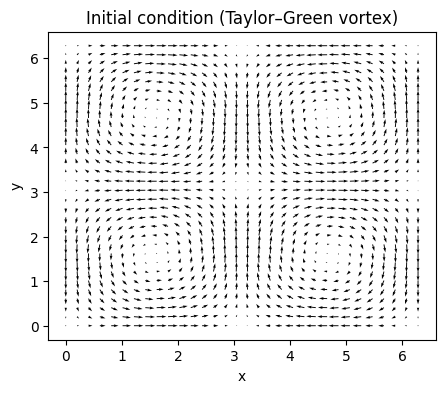

In [7]:
# --- Sanity check: Initial condition pattern ---
Ni = 32
xi = np.linspace(0, 2*np.pi, Ni)
yi = np.linspace(0, 2*np.pi, Ni)
X, Y = np.meshgrid(xi, yi, indexing='ij')
u_ref, v_ref = tg_ic_uv(X, Y)
plt.figure(figsize=(5,4))
plt.quiver(X, Y, u_ref, v_ref)
plt.title("Initial condition (Taylor–Green vortex)")
plt.xlabel("x"); plt.ylabel("y")
plt.show()


[t≤0.0] ep 200/4000 | Total=6.833e-02 IC=1.540e-03 PDE=4.078e-02 Cont=1.215e-02
[t≤0.0] ep 400/4000 | Total=1.978e-02 IC=2.922e-04 PDE=1.321e-02 Cont=3.656e-03
Pred stats: 0.0037225433625280857 0.42827025055885315
[t≤0.0] ep 600/4000 | Total=1.263e-02 IC=2.622e-04 PDE=7.741e-03 Cont=2.267e-03
[t≤0.0] ep 800/4000 | Total=7.445e-03 IC=1.329e-04 PDE=4.675e-03 Cont=1.442e-03
Pred stats: 0.004723692778497934 0.42879167199134827
[t≤0.0] ep 1000/4000 | Total=1.469e-02 IC=9.236e-04 PDE=3.855e-03 Cont=1.597e-03
[t≤0.0] ep 1200/4000 | Total=3.621e-03 IC=3.321e-05 PDE=2.495e-03 Cont=7.933e-04
[t≤0.0] ep 1400/4000 | Total=2.954e-03 IC=4.361e-05 PDE=1.896e-03 Cont=6.225e-04
Pred stats: 0.014032258652150631 0.43169689178466797
[t≤0.0] ep 1600/4000 | Total=3.639e-03 IC=1.427e-04 PDE=1.681e-03 Cont=5.315e-04
[t≤0.0] ep 1800/4000 | Total=1.919e-03 IC=2.339e-05 PDE=1.282e-03 Cont=4.029e-04
Pred stats: 0.028520865365862846 0.432284951210022
[t≤0.0] ep 2000/4000 | Total=1.620e-03 IC=2.169e-05 PDE=1.077e-0

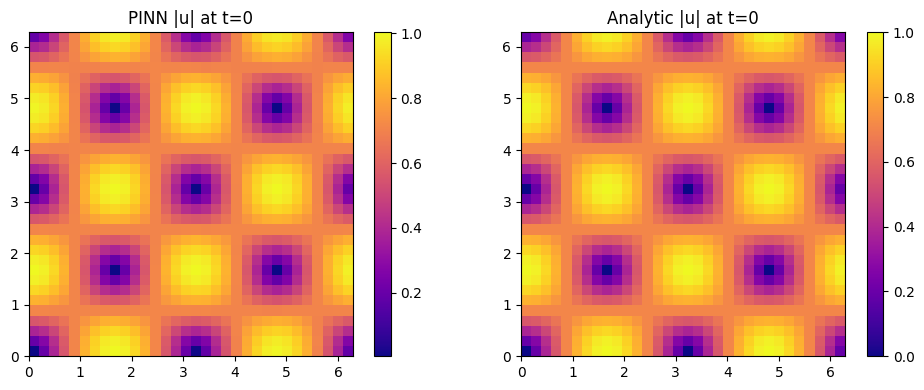

--- Stage complete: t ≤ 0.03 ---


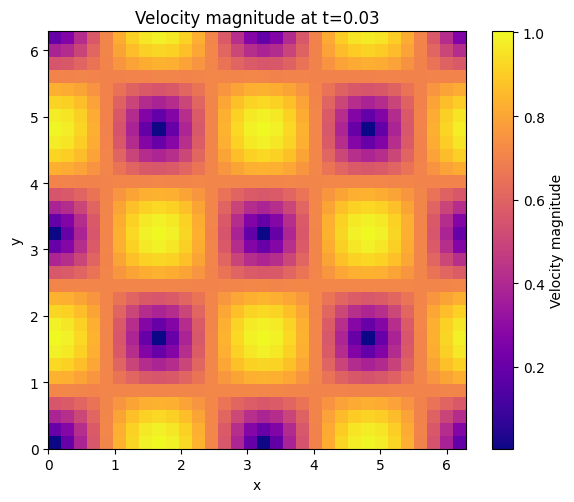

[t≤0.1] ep 200/6000 | Total=3.032e-03 IC=1.500e-04 PDE=1.244e-03 Cont=2.874e-04
[t≤0.1] ep 400/6000 | Total=1.254e-03 IC=3.256e-05 PDE=7.512e-04 Cont=1.774e-04
Pred stats: 0.03156137466430664 0.4285861849784851
[t≤0.1] ep 600/6000 | Total=3.276e-03 IC=2.392e-04 PDE=6.907e-04 Cont=1.934e-04
[t≤0.1] ep 800/6000 | Total=1.235e-03 IC=6.173e-05 PDE=4.857e-04 Cont=1.318e-04
Pred stats: 0.032324984669685364 0.4323844611644745
[t≤0.1] ep 1000/6000 | Total=1.500e-03 IC=9.691e-05 PDE=4.200e-04 Cont=1.111e-04
[t≤0.1] ep 1200/6000 | Total=1.435e-03 IC=9.595e-05 PDE=3.789e-04 Cont=9.689e-05
[t≤0.1] ep 1400/6000 | Total=4.511e-04 IC=1.032e-05 PDE=2.726e-04 Cont=7.532e-05
Pred stats: 0.037359971553087234 0.42813047766685486
[t≤0.1] ep 1600/6000 | Total=1.166e-03 IC=7.509e-05 PDE=3.001e-04 Cont=1.146e-04
[t≤0.1] ep 1800/6000 | Total=6.481e-04 IC=3.545e-05 PDE=2.298e-04 Cont=6.382e-05
Pred stats: 0.030065277591347694 0.43119123578071594
[t≤0.1] ep 2000/6000 | Total=3.097e-03 IC=2.519e-04 PDE=4.021e-04 

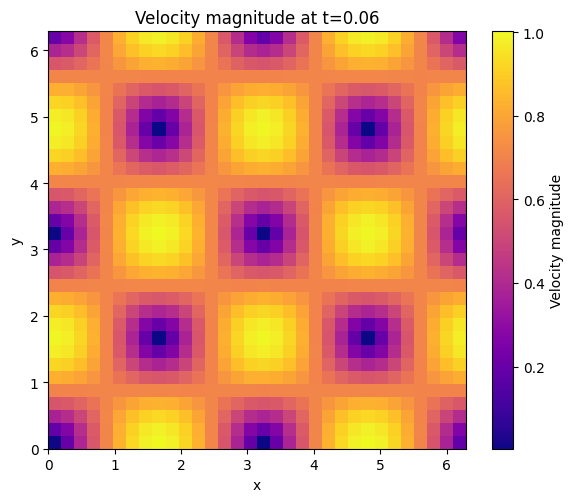

[t≤0.1] ep 200/8000 | Total=3.580e-04 IC=1.505e-06 PDE=3.140e-04 Cont=2.901e-05
[t≤0.1] ep 400/8000 | Total=3.404e-04 IC=3.310e-06 PDE=2.789e-04 Cont=2.840e-05
Pred stats: 0.01895005628466606 0.4347144663333893
[t≤0.1] ep 600/8000 | Total=5.398e-04 IC=2.110e-05 PDE=2.885e-04 Cont=4.038e-05
[t≤0.1] ep 800/8000 | Total=5.016e-04 IC=1.994e-05 PDE=2.650e-04 Cont=3.731e-05
Pred stats: 0.02147788740694523 0.435305655002594
[t≤0.1] ep 1000/8000 | Total=5.344e-04 IC=2.389e-05 PDE=2.595e-04 Cont=3.595e-05
[t≤0.1] ep 1200/8000 | Total=1.525e-03 IC=1.059e-04 PDE=3.512e-04 Cont=1.140e-04
[t≤0.1] ep 1400/8000 | Total=9.643e-04 IC=5.758e-05 PDE=3.343e-04 Cont=5.421e-05
Pred stats: 0.020368456840515137 0.4344739615917206
[t≤0.1] ep 1600/8000 | Total=1.725e-03 IC=1.028e-04 PDE=5.985e-04 Cont=9.877e-05
[t≤0.1] ep 1800/8000 | Total=3.924e-04 IC=1.307e-05 PDE=2.313e-04 Cont=3.038e-05
Pred stats: 0.03735533729195595 0.43384668231010437
[t≤0.1] ep 2000/8000 | Total=7.530e-04 IC=4.438e-05 PDE=2.479e-04 Cont

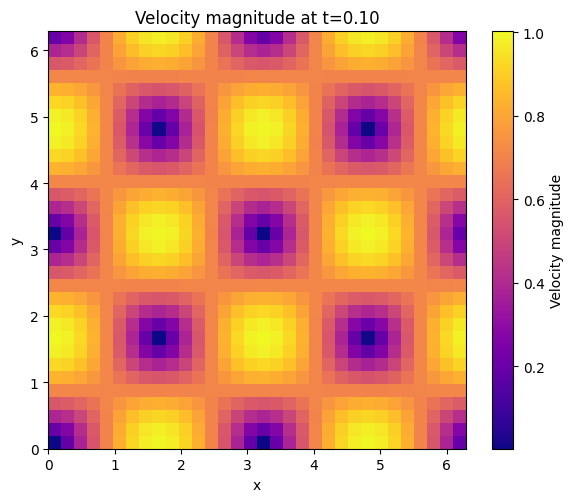

✅ Model saved to ./pinn_outputs/pinn_ns.pt
📊 L2 Error:    1.4049e+00
📊 L∞ Error:    9.9984e-01
📊 Correlation: 0.0001
✅ Saved fields and figures to ./pinn_outputs


In [8]:
# ===========================
# Cell 7 — Train & Evaluate
# ===========================
if __name__ == "__main__":
    model, logs = train_pinn(
        epochs_stages=(4000, 6000, 8000),
        t_stages=(0.03, 0.06, 0.1),
        Nc=5000, Ni=1000, lr=1e-3,
        hidden_dim=128, depth=8, n_fxy=6, n_ft=2,
        save_path=os.path.join(SAVE_DIR, "pinn_ns.pt")
    )
    model.eval()
    run_full_evaluation(model, reference_npz=REFERENCE_NPZ)


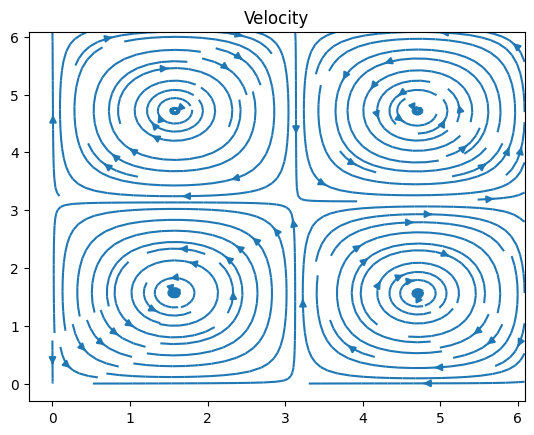

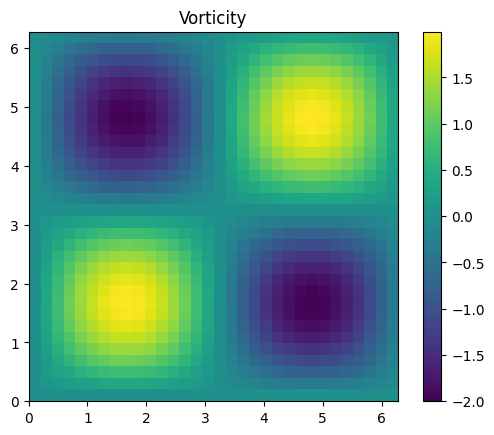

In [9]:
# =========================================
# Cell 8 — (Optional) Quick Visualization
# =========================================
# If you want to quickly check fields without re-loading:
data = np.load(os.path.join(SAVE_DIR, "pinn_fields_t1.npz"))
x, y, u, v, w = data["x"], data["y"], data["u"], data["v"], data["w"]
plt.figure(); plt.streamplot(x, y, u.T, v.T, density=1.2); plt.title("Velocity"); plt.show()
plt.figure(); plt.imshow(w.T, origin='lower', extent=[0,L,0,L]); plt.colorbar(); plt.title("Vorticity"); plt.show()
